# Memoria de Reinforcement Learning aplicado a Space Invaders

**Autores**: Shengkai Zhu, Yixuan Miren Mei, Kaihao Wang
**Asignatura:** Aprendizaje Automático II — Grado en Ciencia de Datos e Inteligencia Artificial  
**Bloque:** Aprendizaje por Refuerzo  

## 1. Motivación del Problema

Space Invaders es un videojuego de 1978 que, pese a su aparente simplicidad, presenta una serie de características que lo convierten en un entorno de prueba idóneo para el Aprendizaje por Refuerzo:

- **Dinámica estocástica**: los disparos enemigos dependen de probabilidades ajustables, lo que obliga al agente a aprender una política robusta ante la incertidumbre, no solo una secuencia memorizada de acciones.

- **Horizonte temporal largo**: una partida puede durar miles de frames, exigiendo que el agente considere consecuencias a largo plazo (gestión de vidas, progresión de nivel).

- **Objetivos múltiples y jerarquizados**: sobrevivir, eliminar enemigos y progresar de nivel son objetivos que pueden estar en conflicto, lo que dificulta el diseño de la función de recompensa.

- **Entorno personalizado**: la implementación propia en Pygame (sin señal de recompensa predefinida por Gymnasium) obliga a diseñar completamente la función de recompensa, reproduciendo los desafíos reales del *reward engineering* en aplicaciones industriales.

Desde la perspectiva de la IA aplicada, los avances en videojuegos de Atari han demostrado ser transferibles a dominios reales: control robótico, planificación autónoma de vehículos y optimización de centros de datos utilizan arquitecturas nacidas en entornos de juego. El diseño de una función de recompensa densa y libre de *reward hacking* anticipa además los problemas del RLHF (*Reinforcement Learning from Human Feedback*) en sistemas de IA de propósito general.


## 2. Modelado del Problema: Formalización MDP

Un **Proceso de Decisión de Markov (MDP)** se define formalmente como la tupla $\mathcal{M} = (\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)$, donde:

| Símbolo | Denominación | Descripción |
|---------|--------------|-------------|
| $\mathcal{S}$ | Espacio de estados | Conjunto de todas las observaciones posibles del entorno |
| $\mathcal{A}$ | Espacio de acciones | Conjunto de decisiones que puede tomar el agente |
| $\mathcal{P}$ | Dinámica de transición | $\mathcal{P}(s' \mid s, a)$: probabilidad de pasar al estado $s'$ tras ejecutar $a$ en $s$ |
| $\mathcal{R}$ | Función de recompensa | $\mathcal{R}(s, a, s')$: señal escalar que retroalimenta al agente |
| $\gamma$ | Factor de descuento | Pondera la importancia de recompensas futuras vs. inmediatas |

La **propiedad de Markov** establece que $\mathbb{P}[s_{t+1} \mid s_t, a_t] = \mathbb{P}[s_{t+1} \mid s_0, a_0, \ldots, s_t, a_t]$: el futuro es independiente del pasado dado el presente. Esta propiedad es fundamental: si el estado codifica toda la información relevante, no se necesita memoria del historial completo.

### 2.1. Espacio de Estados $\mathcal{S}$

**En `rl_vector`** (primera aproximación), el estado es un vector de características numéricas $s_t \in \mathbb{R}^{10}$ extraídas manualmente del estado del juego:

$$s_t = \bigl[x_{\text{player}},\ x_{\text{bullet}},\ y_{\text{bullet}},\ x_{\text{enemy}},\ y_{\text{enemy}},\ \text{vidas},\ \text{nivel},\ \text{cooldown},\ \text{HP\_boss},\ \text{flag\_balas}\bigr]^\top$$

Todas las coordenadas están normalizadas en $[0, 1]$. La ausencia de proyectil activo se codifica como $1.0$, actuando como indicador de ausencia.

Este método fue una buena primera aproximación, pero la selección manual de características limitó la capacidad del agente para aprender patrones complejos (como la trayectoria de los proyectiles enemigos) y gran parte de los patrones de ataque de los enemigos quedaron fuera del espacio de estados, lo que dificultó el aprendizaje de una política óptima. Con el fin de limitar la longitud de la memoria, no hablaremos demasiado de esta versión, aunque se puede consultar el código en `rl_vector.py` para más detalles.

**En `rl_vision`** (arquitectura final), el estado es una pila de $k=4$ frames consecutivos en escala de grises y reducidos a $84 \times 84$ píxeles:

$$s_t = \bigl[f_{t-3},\ f_{t-2},\ f_{t-1},\ f_t\bigr] \in \mathbb{R}^{84 \times 84 \times 4}$$

El apilamiento de frames es necesario para preservar información de velocidad y dirección del movimiento de los proyectiles: un solo frame es ambiguo respecto a la dirección de desplazamiento (la propiedad de Markov se viola con un único frame, ya que la velocidad no es observable).


### 2.2. Espacio de Acciones $\mathcal{A}$

El agente dispone de $|\mathcal{A}| = 4$ acciones discretas:

| ID | Acción | Descripción |
|----|--------|-------------|
| 0 | NOOP | No hacer nada |
| 1 | LEFT | Mover la nave a la izquierda |
| 2 | RIGHT | Mover la nave a la derecha |
| 3 | FIRE | Disparar proyectil |

El espacio de acciones es discreto y pequeño, lo que favorece el uso de métodos *policy-gradient* sobre métodos de actor continuo.

### 2.3. Función de Recompensa $\mathcal{R}$

La función de recompensa es el componente más crítico del diseño MDP y el que mayor iteración requirió a lo largo del proyecto. A continuación se describe cada versión, el comportamiento problemático que la motivó y la solución introducida.

#### Versión 1 — Recompensa dispersa basada en score (`rl_vector`, episodios 0–~5M)

**Código:**
```python
reward += float(score_gain) * 8
reward += 0.005

if level_progress > 0:
    reward += 20.0 * float(level_progress)

if lives_delta < 0:
    reward += float(lives_delta) * 20.0

if self.game.game_over:
    reward -= 100.0

if self._completed_game:
    reward += 120.0

reward = float(np.clip(reward, -20.0, 20.0))
```

**Problema que la motivó:** punto de partida natural. Se asumió que recompensar el score del juego ($+8$ por punto) y penalizar la pérdida de vida ($-20$ por vida) era suficiente para que el agente aprendiese a jugar.

**Problema observado:** el agente aprendió a permanecer inmóvil durante largos periodos (*reward hacking* por inactividad). La señal de recompensa era exclusivamente **dispersa**: el agente podía pasar cientos de frames sin recibir ninguna retroalimentación positiva, lo que enlentecía drásticamente el aprendizaje. En términos del gradiente de política, la estimación de la ventaja $\hat{A}_t$ tenía varianza muy alta al no haber señal intermedia, haciendo las actualizaciones de PPO inestables. Formalmente:

$$\mathbb{E}[\mathcal{R}_1 \mid \text{NOOP siempre}] \approx +0.005t > \mathbb{E}[\mathcal{R}_1 \mid \text{política agresiva}]$$

durante las primeras fases, ya que el riesgo de morir penalizaba más que el beneficio esperado de atacar.

#### Versión 2 — Reward shaping con señal densa (`rl_vision`, episodios ~5M–~13M)

Como nos dimos cuenta que usar un vector de datos, aunque era más sencillo de interpretar, limitaba la capacidad del agente para aprender patrones complejos, decidimos pasar a una representación visual. Al realizar este cambio, también decidimos introducir una función de recompensa distinta con el fin de mitigar el problema de la señal dispersa y algunos problemas de *reward hacking* observados en la versión anterior.

**Código:**
```python
# Score: escala pequeña para no saturar el clip
reward += float(score_gain) * 0.1

# Supervivencia mínima uniforme
reward += 0.0005

# Señal densa de combate
if alien_kills > 0:
    reward += 1.0 * float(alien_kills)
    self._steps_since_last_kill = 0
elif current_alien_count > 0:
    self._steps_since_last_kill += 1
    reward -= min(0.002, 0.00001 * float(self._steps_since_last_kill))

# Bonus al limpiar oleada
if current_alien_count == 0 and self._last_alien_count > 0:
    reward += 4.0

# Penalización por perder vida
if lives_delta < 0:
    reward += float(lives_delta) * 8.0

# Game over
if self.game.game_over:
    reward -= 8.0

# Completar el juego
if self._completed_game:
    reward += 10.0

reward = float(np.clip(reward, -10.0, 10.0))
```


Esta versión incorpora varios cambios motivados por problemas concretos:

##### 2.3.1. Reducción de la escala del score: `score_gain × 0.1`


**Problema:** en la versión anterior, `score_gain × 8` producía picos de recompensa muy grandes al eliminar varios enemigos seguidos, saturando el clip de PPO ($\pm 20$) con frecuencia. Cuando la recompensa se satura, el gradiente efectivo del ratio de importancia $r_t(\theta)$ queda aplastado contra el límite del clip:

$$\mathcal{L}^{\text{CLIP}} = \mathbb{E}_t\!\left[\min\!\left(r_t\hat{A}_t,\;\operatorname{clip}(r_t, 1{-}\varepsilon, 1{+}\varepsilon)\hat{A}_t\right)\right]$$

Si $r_t \hat{A}_t \gg 1{+}\varepsilon$ sistemáticamente, la función objetivo pierde resolución: todas las acciones buenas reciben el mismo gradiente. 

**Solución:** escalar el score a $\times 0.1$ para que los eventos de combate contribuyan con valores del orden de $[0.1, 1.0]$, dentro del margen útil del clip.

##### 2.3.2. Señal de supervivencia por frame: `+0.0005`

**Problema:** sin señal positiva frame a frame, el gradiente entre eventos de recompensa era nulo, lo que ralentizaba la convergencia de la función de valor $V_\theta(s)$. El crítico no tenía información suficiente para diferenciar estados intermedios.

**Solución:** añadir una recompensa constante pequeña por cada frame sobrevivido. Esto crea un incentivo continuo hacia la supervivencia sin distorsionar la jerarquía de recompensas (matar enemigos sigue valiendo más). Se eligió $0.0005$ por ser del orden de $10^{-3}$ respecto al valor de un kill ($+1.0$), garantizando que la señal de supervivencia no domine sobre la de combate.

##### 2.3.3. Señal densa de combate y penalización progresiva por inactividad

**Problema:** el agente seguía mostrando tendencia a no disparar, especialmente cuando aprender a esquivar balas era suficiente para mantener la recompensa de supervivencia positiva.

**Solución en dos partes:**

- **Recompensa directa por eliminación** (`+1.0 × alien_kills`): señal inmediata vinculada a la acción de disparar y acertar, en lugar de al score retardado del juego. Esto reduce el *delay* entre la acción y la recompensa, facilitando la asignación de crédito (*credit assignment*).

- **Penalización progresiva por estancamiento:**
```python
reward -= min(0.002, 0.00001 * float(self._steps_since_last_kill))
```
La penalización crece linealmente con los steps transcurridos desde el último kill, hasta un máximo de $0.002$. Matemáticamente:

$$p_t = \min\!\left(0.002,\; 10^{-5} \cdot t_{\text{idle}}\right)$$

La función $\min$ evita que la penalización crezca indefinidamente y domine la señal de recompensa. El umbral de $0.002$ equivale a que el agente necesita matar un enemigo cada $\sim\!200$ steps para mantenerse neutro respecto a esta componente.

##### 2.3.4. Bonus por limpiar oleada: `+4.0`

**Problema:** eliminar el último enemigo de una oleada no generaba ninguna señal especial, por lo que el agente no aprendía a dar prioridad a completar las oleadas (objetivo necesario para progresar de nivel).

**Solución:** recompensa puntual al vaciar el grupo de aliens (`current_alien_count == 0 and self._last_alien_count > 0`). El valor $+4.0$ se escogió como múltiplo del valor por kill individual ($+1.0$), reforzando que completar una oleada es cualitativamente más valioso que un kill aislado.


##### 2.3.5. Reescalado de la penalización por muerte: `lives_delta × 8.0` y `game_over −8.0`

**Problema:** en la versión anterior, la penalización por muerte era $-20$ y el clip era $\pm 20$, lo que significaba que una sola muerte consumía casi todo el margen de penalización disponible, aplastando cualquier otra señal negativa que pudiese ocurrir en el mismo step.

**Solución:** reducir la penalización a $-8$ por vida (sincronizada con el clip reducido a $\pm 10$) y separar la penalización de game over ($-8$) de la pérdida de vida, de forma que el agente pueda distinguir entre "perder una vida pero sobrevivir" y "terminar la partida".

##### 2.3.6. Bonus por completar el juego: `+10.0`

**Problema:** sin señal terminal positiva, el agente no tenía incentivo explícito a completar el nivel 4 (derrota del BrainCell), pues el juego termina en ese momento y ya no hay más recompensa de supervivencia.

**Solución:** recompensa terminal única al detectar `self._completed_game = True`. El valor $+10.0$ equivale al máximo del clip, estableciendo la victoria total como el objetivo de mayor recompensa posible en un solo step.


##### 2.3.7. Clip reducido a $\pm 10$


**Problema:** el clip anterior de $\pm 20$ permitía que eventos excepcionales (matar 5 enemigos de un disparo de escopeta en el nivel 3) dominasen el gradiente durante varios pasos de optimización.

**Solución:** reducir el clip a $\pm 10$ normaliza la escala de recompensas y asegura que el ratio de importancia $r_t(\theta)$ en el objetivo PPO opera en un rango de ventajas $\hat{A}_t$ consistente con los hiperparámetros elegidos ($\varepsilon = 0.2$, $c_1 = 0.5$).

#### Resumen comparativo de versiones

| Componente | v1 (`rl_vector`) | v2 (`rl_vision`) | Motivo del cambio |
|---|---|---|---|
| Score | `× 8` | `× 0.1` | Saturación del clip |
| Supervivencia/frame | `+0.005` | `+0.0005` | Ajuste a nueva escala |
| Kill directo | ✗ | `+1.0 × kills` | Credit assignment |
| Penaliz. inactividad | ✗ | `−min(0.002, 0.00001·t)` | Reward hacking por pasividad |
| Bonus oleada completa | ✗ | `+4.0` | Progresar de nivel |
| Penaliz. muerte | `× −20` | `× −8` | Saturación del clip |
| Game over | `−100` | `−8` | Demasiado dominante |
| Completar juego | `+120` | `+10` | Fuera de rango del clip |
| Clip | `±20` | `±10` | Estabilidad del gradiente PPO |

### 2.4. Dinámica de Transición $\mathcal{P}$

El entorno es **estocástico**: $\mathcal{P}(s' \mid s, a) \neq \{0, 1\}$ en general. Las fuentes de aleatoriedad son:
- Probabilidad de disparo de los enemigos (parámetro ajustable).
- Ángulo de los proyectiles de los Tech Aliens: $\theta \sim \mathcal{U}[\theta_{\min}, \theta_{\max}]$.
- Posición de teletransporte de los Tech Aliens: $x \sim \mathcal{U}[0, W_{\text{pantalla}}]$.
- El comportamiento del jefe final (nivel 4) es parcialmente aleatorio, con patrones de ataque que varían entre partidas.

El entorno es **episódico**: cada episodio comienza en un estado inicial fijo ($x_{\text{player}} = W/2$, $\text{vidas} = 3$, nivel 1) y termina en un estado terminal (todas las vidas perdidas o nivel 4 completado).

### 2.5. Factor de Descuento $\gamma$


Se eligió $\gamma = 0.99$. La justificación matemática es la siguiente:

El **retorno descontado** desde el paso $t$ es:
$$G_t = \sum_{k=0}^{\infty} \gamma^k \mathcal{R}_{t+k+1}$$

Con $\gamma = 0.99$, el peso de una recompensa $k$ pasos en el futuro es $0.99^k$. Para $k = 100$ pasos: $0.99^{100} \approx 0.366$, lo que significa que las recompensas a 100 frames vista todavía tienen más de un tercio del peso de las inmediatas. Esto es adecuado para un juego donde completar un nivel puede ocurrir cientos de frames después de las acciones que lo hicieron posible.

Un valor $\gamma < 0.95$ haría al agente demasiado miope, ignorando objetivos lejanos como el bonus de nivel. Un valor $\gamma = 1$ (sin descuento) en entornos episódicos puede funcionar, pero dificulta la convergencia de la función de valor en la práctica.


## 3. Breve Estado del Arte

- **Heurísticas clásicas y jugadores automáticos por reglas**

    Antes de que el Aprendizaje por Refuerzo dominase el campo, los videojuegos de arcade como Space Invaders se abordaban principalmente mediante dos estrategias. La primera eran los **bots basados en reglas**: programas que codificaban explícitamente el comportamiento óptimo conocido por un jugador humano experto, como "moverse hacia el alien más próximo al jugador", "disparar cuando el jugador esté alineado verticalmente con un enemigo" o "esquivar la bala más cercana". Estas soluciones funcionaban razonablemente bien en el juego original de Atari, donde el comportamiento de los enemigos es perfectamente predecible y periódico. Sin embargo, presentaban dos limitaciones fundamentales: dependían completamente del conocimiento previo del diseñador, y no generalizaban en absoluto ante variaciones del entorno, como enemigos con comportamientos nuevos (Tech Aliens con teletransporte) o un jefe con múltiples patrones de ataque como el BrainCell de este proyecto.

    La segunda estrategia fue el uso de **algoritmos de búsqueda**. Técnicas como minimax, alpha-beta pruning o incluso búsqueda en árbol de Monte Carlo (MCTS) son aplicables en principio a juegos de un solo jugador si se dispone de un modelo del entorno. No obstante, en Space Invaders el espacio de estados es continuo (posiciones en píxeles), los enemigos tienen comportamientos estocásticos, y la frecuencia de frames hace que construir un árbol de búsqueda en tiempo real sea computacionalmente inviable. Estas limitaciones motivaron la búsqueda de aproximaciones basadas en aprendizaje.


- **DQN y el nacimiento del Deep RL aplicado a videojuegos**

    El trabajo de Mnih et al. (2013, 2015) en DeepMind supuso una revolución en el campo. Su algoritmo **DQN (Deep Q-Network)** [1] demostró por primera vez que un agente podía aprender a jugar a 49 juegos de Atari 2600 —incluyendo Space Invaders— directamente a partir de píxeles en bruto, sin ningún conocimiento previo del juego, alcanzando rendimiento sobrehumano en la mayoría de ellos. Los dos ingredientes clave que hacían funcionar DQN eran el **Experience Replay** (guardar transiciones en un buffer y muestrear minibatches aleatorios para romper la correlación temporal de los datos) y la **Target Network** (una copia desincronizada de la red principal que estabilizaba el objetivo de entrenamiento).

    En el caso concreto de Space Invaders, DQN alcanzó aproximadamente 1.976 puntos, superando la media humana de referencia. Sin embargo, los propios autores reconocieron que el juego presentaba características que dificultaban al algoritmo: la necesidad de planificar a largo plazo (hay que limpiar oleadas enteras para avanzar) y la alta densidad de proyectiles enemigos en niveles avanzados, que requerían esquiva precisa y no solo disparo. Estas limitaciones son especialmente relevantes en la versión personalizada de este proyecto, donde el nivel 4 con el BrainCell supone una escalada de dificultad muy superior al juego original.

    La arquitectura CNN utilizada en DQN —tres capas convolucionales seguidas de capas totalmente conectadas— se convirtió en el estándar para procesar observaciones visuales en RL.

- **Mejoras sobre DQN: Double DQN, Dueling y Prioritized Experience Replay**

    Tras el éxito de DQN, una intensa línea de investigación buscó corregir sus debilidades conocidas.

    **Double DQN** (van Hasselt et al., 2016) [2] identificó que DQN tenía tendencia a sobreestimar sistemáticamente los valores Q, especialmente en estados ruidosos. La causa era que el mismo conjunto de pesos se usaba tanto para seleccionar la mejor acción como para evaluar su valor. Double DQN desacopló estos dos roles usando la red principal para elegir la acción y la target network para evaluarla, reduciendo el sesgo de estimación y mejorando el rendimiento en la mayoría de juegos de Atari.

    **Dueling DQN** (Wang et al., 2016) propuso una arquitectura que separaba explícitamente la estimación del valor del estado $V(s)$ y la ventaja de cada acción $A(s, a)$, combinándolas al final. Esto resultaba especialmente útil en estados donde la elección de acción específica importa poco (por ejemplo, cuando no hay enemigos cerca y cualquier movimiento es igualmente válido), situación frecuente en los niveles intermedios de Space Invaders durante los periodos de reposicionamiento del jugador.

    **Prioritized Experience Replay** (Schaul et al., 2016) abordó la ineficiencia de muestrear el replay buffer de forma uniforme. Las transiciones con mayor error de Bellman (aquellas donde la estimación actual del valor estaba más lejos de la realidad) se muestreaban con mayor frecuencia, acelerando el aprendizaje en entornos con recompensas dispersas. En Space Invaders, donde los kills son eventos relativamente poco frecuentes comparados con los frames de simple movimiento, este mecanismo tiene especial relevancia.

    El trabajo de Hessel et al. (2018) **Rainbow** [3] combinó las seis extensiones más relevantes de DQN en un único agente, logrando resultados significativamente superiores en el benchmark ALE. En Space Invaders, Rainbow alcanzó más de 18.000 puntos, frente a los ~1.976 de DQN original, lo que ilustra hasta qué punto las mejoras algorítmicas eran acumulativas y complementarias.


- **Métodos basados en gradiente de política:**

    En paralelo al desarrollo de los métodos basados en función Q, otra línea de investigación trabajó directamente sobre la política. Los métodos de **gradiente de política** (REINFORCE, Williams 1992) optimizan directamente los parámetros de la política sin necesidad de estimar una función de valor. Aunque teóricamente más directos, estos métodos sufrían de alta varianza en la estimación del gradiente, lo que los hacía inestables en entornos complejos.

    Los métodos **actor-crítico** surgieron como solución a este problema: combinan un actor (la política) con un crítico (la función de valor) que reduce la varianza del gradiente al proporcionar una línea base de referencia. El algoritmo **A3C (Asynchronous Advantage Actor-Critic)** de Mnih et al. (2016) extendió este enfoque al entrenamiento asíncrono con múltiples agentes en paralelo, cada uno explorando el entorno de forma independiente y enviando gradientes al modelo central. Esto no solo aceleraba el entrenamiento sino que también mejoraba la diversidad de experiencias, reduciendo la correlación entre muestras sin necesidad de un replay buffer.

    **A2C (Advantage Actor-Critic)**, la versión síncrona de A3C, fue la implementación de referencia adoptada más tarde por librerías como Stable-Baselines3 debido a su mayor reproducibilidad. En experimentos preliminares de este proyecto se probó A2C antes de migrar a PPO, observándose que A2C era más inestable y requería un ajuste fino de la tasa de aprendizaje mucho más cuidadoso.

- **PPO**
    El algoritmo **PPO (Proximal Policy Optimization)** fue publicado por OpenAI en 2017 [4] como una versión simplificada y más estable de su antecesor TRPO (Trust Region Policy Optimization). Mientras TRPO imponía una restricción matemática estricta sobre el tamaño del paso de actualización (usando una región de confianza definida mediante la divergencia KL entre la política vieja y la nueva), PPO consigue una restricción similar pero mediante un simple clipping del ratio de importancia, lo que lo hace mucho más fácil de implementar y computacionalmente más eficiente.

    PPO se convirtió rápidamente en el algoritmo de RL más ampliamente utilizado tanto en investigación como en industria, por varias razones. Es notablemente robusto a variaciones en los hiperparámetros, lo que facilita su aplicación a nuevos entornos sin búsqueda exhaustiva. Es compatible con espacios de acción tanto discretos (como los 5 movimientos de este proyecto) como continuos. Y, a diferencia de DQN, es un algoritmo **on-policy**, lo que significa que aprende directamente de la política actual sin necesidad de mantener un replay buffer, simplificando la implementación en entornos con múltiples instancias paralelas como el utilizado en este proyecto (`SubprocVecEnv` de Stable-Baselines3).

    En el contexto de juegos de Atari, PPO supera consistentemente a DQN en términos de eficiencia de muestras cuando se usan múltiples entornos paralelos, que fue precisamente la estrategia adoptada en este proyecto (hasta 12 entornos paralelos en fases avanzadas de entrenamiento).


- **El benchmark ALE y la comparación estandarizada**

    El **Arcade Learning Environment (ALE)** (Bellemare et al., 2013) [5] fue el primer framework que estandarizó la evaluación de agentes de RL en videojuegos de Atari, proporcionando una interfaz común y métricas de comparación comparables entre trabajos. ALE incluyó Space Invaders como uno de sus 57 juegos de referencia y estableció que la puntuación humana de referencia era de aproximadamente 1.652 puntos en el juego original.

    Este benchmark permitió comparar objetivamente el progreso del campo a lo largo de los años. Desde los ~1.976 puntos de DQN (2015) hasta los ~18.789 puntos de Rainbow (2018) y los resultados aún superiores de métodos más recientes como MuZero o Agent57, la evolución refleja décadas de mejoras acumulativas en arquitecturas, algoritmos y técnicas de entrenamiento.

    Es importante destacar que los benchmarks de ALE usaban el juego original de Atari, significativamente más sencillo que el entorno personalizado de este proyecto: los aliens del juego original tienen un único patrón de movimiento determinista, mientras que el entorno de este proyecto introduce Tech Aliens con teletransporte aleatorio, un jefe con múltiples fases y comportamiento emergente, y cuatro niveles de dificultad creciente que exigen estrategias cualitativamente distintas en cada uno.

- **OpenAI Five y AlphaStar**
    El trabajo **OpenAI Five** (Berner et al., 2019) [6] demostró que PPO podía escalar a entornos de complejidad radicalmente superior a los juegos de Atari. Usando miles de CPUs en paralelo y entrenando durante meses con cientos de miles de millones de steps, el sistema consiguió derrotar a equipos profesionales humanos en Dota 2, un juego de estrategia en tiempo real con espacio de acciones de altísima dimensionalidad, planificación a largo plazo y coordinación de múltiples agentes. Aunque la escala de ese proyecto está muy alejada de este trabajo, las técnicas utilizadas —PPO con GAE, entrenamiento distribuido, curriculum learning, y reward shaping cuidadoso— son directamente las mismas que se aplicaron aquí a menor escala.

    De forma similar, **AlphaStar** de DeepMind (Vinyals et al., 2019) aplicó técnicas de RL con redes LSTM y autoaprendizaje (*self-play*) para dominar StarCraft II. Ambos proyectos confirmaron que el diseño de la función de recompensa y el curriculum de entrenamiento eran los factores más determinantes del éxito, por encima de los detalles específicos del algoritmo, una conclusión que este proyecto reproduce a pequeña escala: los mayores saltos de rendimiento se produjeron al revisar la función de recompensa, no al cambiar de arquitectura.

- **Trabajos específicos sobre aprendizaje en juegos tipo shoot 'em up**

    Más allá del Space Invaders original de Atari, la categoría de juegos *shoot 'em up* ha recibido atención específica en la literatura de RL. Liao et al. (2012) estudiaron agentes de Q-Learning tabular en versiones simplificadas de Space Invaders, concluyendo que la representación del estado era el factor más crítico: agentes con features bien diseñadas (posición del jugador y enemigos más próximos) superaban ampliamente a agentes que recibían el frame completo de píxeles cuando el presupuesto de entrenamiento era limitado. Esta observación motivó directamente el diseño del modelo `rl_vector` como primera aproximación en este proyecto, antes de migrar a la representación visual.

    Estudios más recientes sobre generalización en juegos de Atari (Farebrother et al., 2018; Cobbe et al., 2019) han demostrado que los agentes de Deep RL tienden a sobreajustarse al entorno de entrenamiento específico, fallando al generalizar incluso ante variaciones menores como cambios de color o velocidad. Este problema de sobreajuste no fue una preocupación mayor en este proyecto al existir un único entorno, pero sería relevante si se quisiera aplicar el agente entrenado a versiones modificadas del juego.

- **Relevancia de las técnicas utilizadas en este proyecto**
    En síntesis, la elección de PPO como algoritmo principal está respaldada por una sólida base bibliográfica: es el algoritmo que mejor combina estabilidad, eficiencia computacional y facilidad de implementación para entornos con espacios de acción discretos y observaciones tanto vectoriales como visuales. Las dos arquitecturas exploradas en este proyecto —`rl_vector` con MLP sobre features manuales y `rl_vision` con CNN sobre frames apilados— replican respectivamente el enfoque de Liao et al. y el de Mnih et al., permitiendo una comparación directamente alineada con la literatura existente.

    El diseño iterativo de la función de recompensa, que se documenta en detalle en la sección 2.3, reproduce a pequeña escala los mismos desafíos de *reward engineering* que se documentan en los trabajos de OpenAI y DeepMind para entornos más complejos, reforzando la relevancia del problema más allá del ámbito académico.


### Referencias

- [1] Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). *Human-level control through deep reinforcement learning*. **Nature**, 518(7540), 529–533.
- [2] van Hasselt, H., Guez, A., & Silver, D. (2016). *Deep reinforcement learning with double Q-learning*. **AAAI**, 30(1).
- [3] Hessel, M., et al. (2018). *Rainbow: Combining improvements in deep reinforcement learning*. **AAAI**, 32(1).
- [4] Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). *Proximal Policy Optimization Algorithms*. arXiv:1707.06347.
- [5] Bellemare, M. G., Naddaf, Y., Veness, J., & Bowling, M. (2013). *The Arcade Learning Environment: An Evaluation Platform for General Agents*. **JAIR**, 47, 253–279.
- [6] Berner, C., et al. (2019). *Dota 2 with Large Scale Deep Reinforcement Learning*. arXiv:1912.06680.
- [7] Wang, Z., et al. (2016). *Dueling network architectures for deep reinforcement learning*. **ICML**.
- [8] Schaul, T., et al. (2016). *Prioritized experience replay*. **ICLR**.
- [9] Schulman, J., Moritz, P., Levine, S., Jordan, M., & Abbeel, P. (2016). *High-dimensional continuous control using generalized advantage estimation*. **ICLR**.
- [10] Vinyals, O., et al. (2019). *Grandmaster level in StarCraft II using multi-agent reinforcement learning*. **Nature**, 575, 350–354.

## 4. Arquitecturas Propuestas

### 4.1. `rl_vector` — MLP sobre vector de características



#### Descripción



La primera aproximación consiste en extraer manualmente un conjunto reducido de características numéricas del estado del juego y alimentarlas a una red MLP (*Multi-Layer Perceptron*)

Lo bueno del método es que tiene un aprendizaje rápido (~3M episodios hasta primeros resultados), bajo coste computacional (0.8 ms/step en CPU). Sin embargo, no es capaz de detectar patrones espaciales complejos, alcanza meseta más baja. 

### 4.2. `rl_vision` — CNN sobre frames de píxeles

#### Descripción



CVada frame se convierte a escala de grises, se redimensiona a $96 \times 112$ px y se apilan $k=4$ frames consecutivos, produciendo un tensor $(4, 112, 96)$. El apilamiento de frames es necesario para preservar la **propiedad de Markov**: un único frame estático no contiene información sobre la velocidad ni dirección de los proyectiles, haciendo el estado parcialmente observable.

En ambas arquitecturas se usa **SiLU** ($f(x) = x \cdot \sigma(x)$) como activación en lugar de ReLU. SiLU es suave y diferenciable en todo su dominio, permite activaciones levemente negativas (evitando neuronas muertas) y ha demostrado empíricamente mejores resultados en benchmarks de visión y RL. Ambas terminan con una capa **LayerNorm** sobre la representación latente para estabilizar la escala de las activaciones que recibe la cabeza actor-crítico de PPO.

Tenemos entonces una red de tres capas convolucionales inspirada en DQN, con SiLU en lugar de ReLU y pooling global al final:
```
(4,112,96) → Conv(8×8,s=4,32) → Conv(4×4,s=2,64) → Conv(3×3,s=1,64)
→ AdaptiveAvgPool2d(1×1) → Flatten → FC(64→256) + SiLU + LayerNorm

Una visualización general de los componentes de la arquitectura sería:

- **Convoluciones (`nn.Conv2d`)**
    - Componente central del extractor visual.
    - Aplican filtros aprendibles que se deslizan por la imagen y detectan patrones locales.
    - Las primeras capas aprenden características de bajo nivel:
        - bordes de sprites
        - contornos de proyectiles
    - Las capas más profundas combinan esas respuestas en representaciones de alto nivel:
        - posición de un alien
        - trayectoria de una bala
        - presencia del jefe
    - Se usan kernels de $3\times3$ en los bloques residuales:
        - tamaño estándar en redes modernas
        - buen equilibrio entre contexto local y eficiencia
    - La convolución inicial usa kernel $5\times5$:
        - captura un campo receptivo algo mayor
        - útil para sprites con varios píxeles de anchura
    - `stride=2` en convoluciones de downsampling:
        - reduce a la mitad la resolución espacial
        - comprime la información
        - reduce el coste computacional
    - Al disminuir la resolución, aumentan los canales:
        - compensa la pérdida de capacidad representacional

- **Pooling global (`nn.AdaptiveAvgPool2d(1, 1)`)**
    - Reduce cada mapa de características a un único escalar mediante la media espacial.
    - Produce un vector de longitud igual al número de canales.
    - Ventajas:
        - elimina la dependencia del tamaño de entrada
        - reduce drásticamente el número de parámetros de la capa siguiente

- **Capas totalmente conectadas (`nn.Linear`)**
    - Tras el pooling global, proyectan el vector de 224 dimensiones al espacio latente final de 384 dimensiones.
    - Aprenden combinaciones lineales de las características extraídas por el backbone.
    - Construyen la representación que recibirán las cabezas actor y crítico de PPO.
    - En `rl_vector`, las capas FC constituyen toda la red y procesan directamente el vector de features manuales.

- **Normalización por grupos (`nn.GroupNorm`)**
    - Normaliza las activaciones dentro de grupos de canales.
    - Resta la media y divide por la desviación estándar por muestra.
    - Se eligió sobre BatchNorm porque:
        - BatchNorm depende del minibatch completo
        - puede ser inestable con minibatches pequeños
    - GroupNorm no depende del tamaño del batch:
        - comportamiento estable con distintos números de entornos paralelos
        - comportamiento estable con distintos minibatches

- **Normalización de capa (`nn.LayerNorm`)**
    - Se aplica en la cabeza de proyección, antes de llegar a la política.
    - Normaliza todas las activaciones de un vector.
    - Objetivo:
        - estabilizar la escala de los valores que recibe PPO
        - evitar variaciones grandes entre episodios
        - facilitar la convergencia

- **SiLU (`nn.SiLU`)**
    - Activación definida como $f(x) = x \cdot \sigma(x)$.
    - A diferencia de ReLU:
        - no anula totalmente las activaciones negativas
        - es suave y diferenciable en todo su dominio
    - Beneficios:
        - evita el problema de *dying ReLU*
        - mantiene neuronas activas
        - proporciona un gradiente más rico
    - En redes profundas, ayuda especialmente en capas cercanas a la entrada.

- **Dropout sobre mapas de características (`nn.Dropout2d`)**
    - Durante el entrenamiento, anula aleatoriamente mapas completos de características.
    - Probabilidad usada: $p=0.10$.
    - En lugar de silenciar píxeles individuales:
        - silencia canales enteros
    - Efectos:
        - evita depender de un único canal
        - distribuye la información entre varias representaciones
        - mejora la robustez visual

- **DropPath — profundidad estocástica (`DropPath`)**
    - Específico de redes residuales.
    - Durante el entrenamiento, algunos bloques residuales se omiten por completo.
    - La señal pasa por la conexión skip como si el bloque no existiese.
    - Los bloques más profundos tienen mayor probabilidad de ser omitidos.
    - Efectos:
        - regularización
        - entrenamiento de una especie de ensamblado de redes de distintas profundidades
        - reducción del coste computacional medio
    - En inferencia, se desactiva.

- **Squeeze-and-Excitation (`SqueezeExcitation`)**
    - Mecanismo de atención sobre canales.
    - Funcionamiento:
        - **squeeze**: resume cada mapa de características con pooling global
        - **excitation**: dos convoluciones $1\times1$ con SiLU generan pesos en $[0,1]$
        - esos pesos reescalan cada canal
    - Efecto:
        - amplifica canales relevantes
        - suprime canales poco informativos
    - En Space Invaders es útil porque la relevancia de los canales cambia según el contexto:
        - proyectiles
        - BrainCell
        - formación de aliens

## 5. Diseño Experimental

### 5.1. Algoritmo: PPO

PPO es un método **on-policy**: el agente aprende de experiencias generadas con su política actual $\pi_\theta$. Tras cada rollout de $n_{\text{steps}}$ transiciones, actualiza los pesos mediante $K$ epochs de descenso de gradiente, y descarta los datos. Esto contrasta con los métodos **off-policy** (como DQN), que reutilizan transiciones antiguas de un replay buffer.

### 5.2. Tabla de Hiperparámetros

| Hiperparámetro | Símbolo | Valor | Justificación |
|----------------|---------|-------|---------------|
| Learning rate | $\alpha$ | $3 \times 10^{-4}$ | Estándar Adam para PPO en entornos Atari |
| Clip ratio | $\varepsilon$ | $0.2$ | Equilibrio entre velocidad de aprendizaje y estabilidad |
| Rollout length | $n_{\text{steps}}$ | $2048$ | Horizonte largo para crédito temporal en episodios extensos |
| Mini-batch size | $B$ | $64$ | Balance entre varianza del gradiente y tiempo de cómputo |
| Epochs por update | $K$ | $10$ | Reutilización de datos sin sobreajuste |
| Factor de descuento | $\gamma$ | $0.99$ | Ver sección 2.5 |
| GAE $\lambda$ | $\lambda$ | $0.95$ | Estándar PPO; reduce varianza del advantage |
| Coef. entropía | $c_2$ | $0.03$ | Incentivo leve a la exploración durante todo el entrenamiento |
| Coef. value loss | $c_1$ | $0.5$ | Equilibrio entre actor y crítico |
| Total episodios | — | $\approx 22 \times 10^6$ | Entrenamiento distribuido en sesiones |

Tener en cuenta que estos hiperparámetros cambiaron a lo largo del entrenamiento (en algunos momentos, se tuvo que aumentar la entropía para asegurar la exploración en niveles avanzados). 

En algunos casos, se realizaron entrenamientos ajustados a niveles específicos (por ejemplo, entrenar solo en el nivel 4 para que el agente aprendiera a derrotar al BrainCell), lo que implicó ajustar la tasa de aprendizaje para evitar sobreajuste a ese nivel.

### 5.3. Mecanismo de Continue Training

Dado que 22 millones de episodios representan decenas de horas de cómputo ininterrumpido, no era factible mantener el ordenador encendido en una única sesión. Se implementó un sistema de **checkpointing** que guarda periódicamente:

- Los pesos de la red neuronal $\theta$ (política + función de valor)
- El estado del optimizador Adam (momentos de primer y segundo orden)
- El número de steps totales acumulados
- Las estadísticas de normalización del observador (media y varianza del estado)

El entrenamiento se reanuda cargando el checkpoint más reciente. Este mecanismo ofrece además la ventaja de poder **comparar modelos intermedios** y **revertir** a versiones anteriores si una actualización de la función de recompensa empeoraba el rendimiento, como ocurrió en los cambios v1→v2 y v2→v3.

Un beneficio adicional no esperado fue que el agente actuaba como **detector de bugs**: durante las primeras fases de evaluación se observaron comportamientos anómalos (el agente disparaba repetidamente sin cooldown), lo que llevó a descubrir un error en la implementación del flag de cooldown en el entorno propio.

Además de eso, se implementó un t-test para comparar estadísticamente el rendimiento de dos checkpoints diferentes, asegurando que las mejoras observadas tras cambios en la función de recompensa eran significativas y no debidas a la varianza inherente al entrenamiento de RL.

### 5.4. Resultados Experimentales

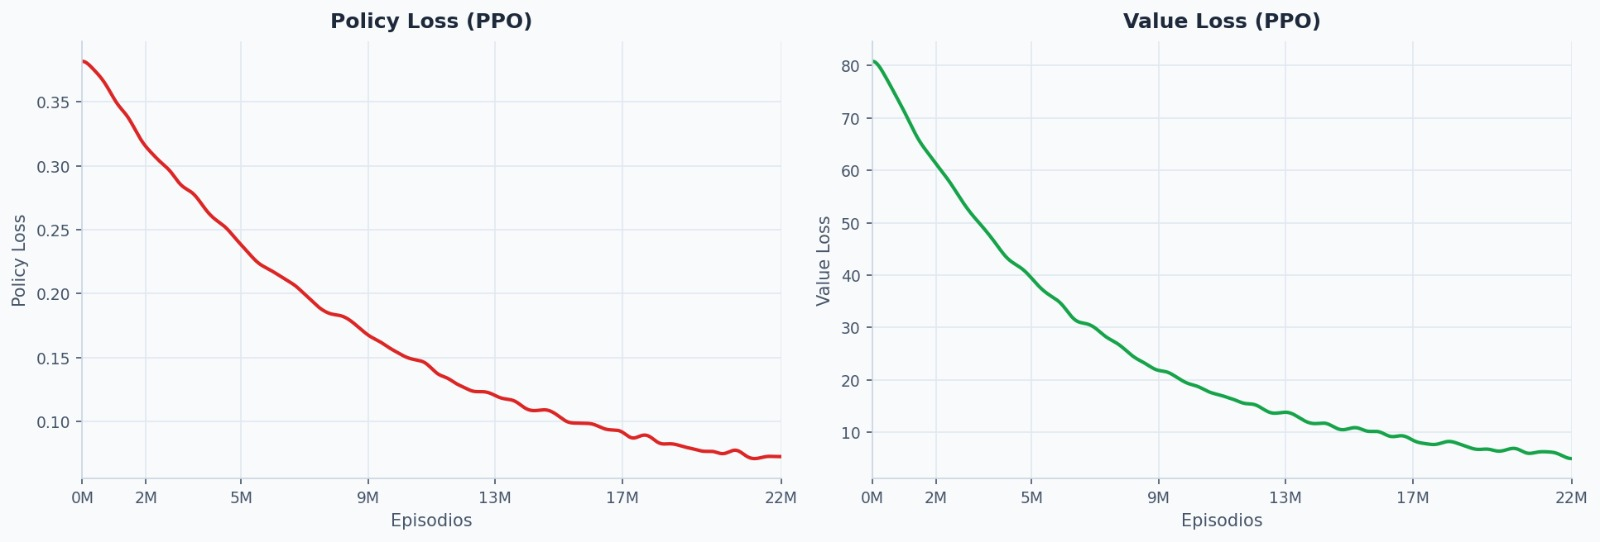

In [5]:
from IPython.display import Image, display


display(Image(filename='graficas_1.jpeg'))

*Figura 1. Izquierda: Policy Loss. Derecha: Value Loss. Ambas convergen de forma consistente.*

La **Policy Loss** $\mathcal{L}^{\text{CLIP}}$ decrece desde ~0.35 hasta estabilizarse en ~0.04. Este valor residual no es cero porque la función clipping de PPO limita intencionadamente el tamaño de las actualizaciones; una policy loss muy baja indicaría actualizaciones negligibles.

La **Value Loss** $\mathcal{L}^{\text{VF}} = \mathbb{E}[(V_\theta(s_t) - V^{\text{target}}_t)^2]$ cae de ~80 a ~3. Las irregularidades en los 5M y 13M de episodios corresponden a los cambios en la función de recompensa, que modifican la distribución de $V^{\text{target}}$ y obligan al crítico a reaprender.


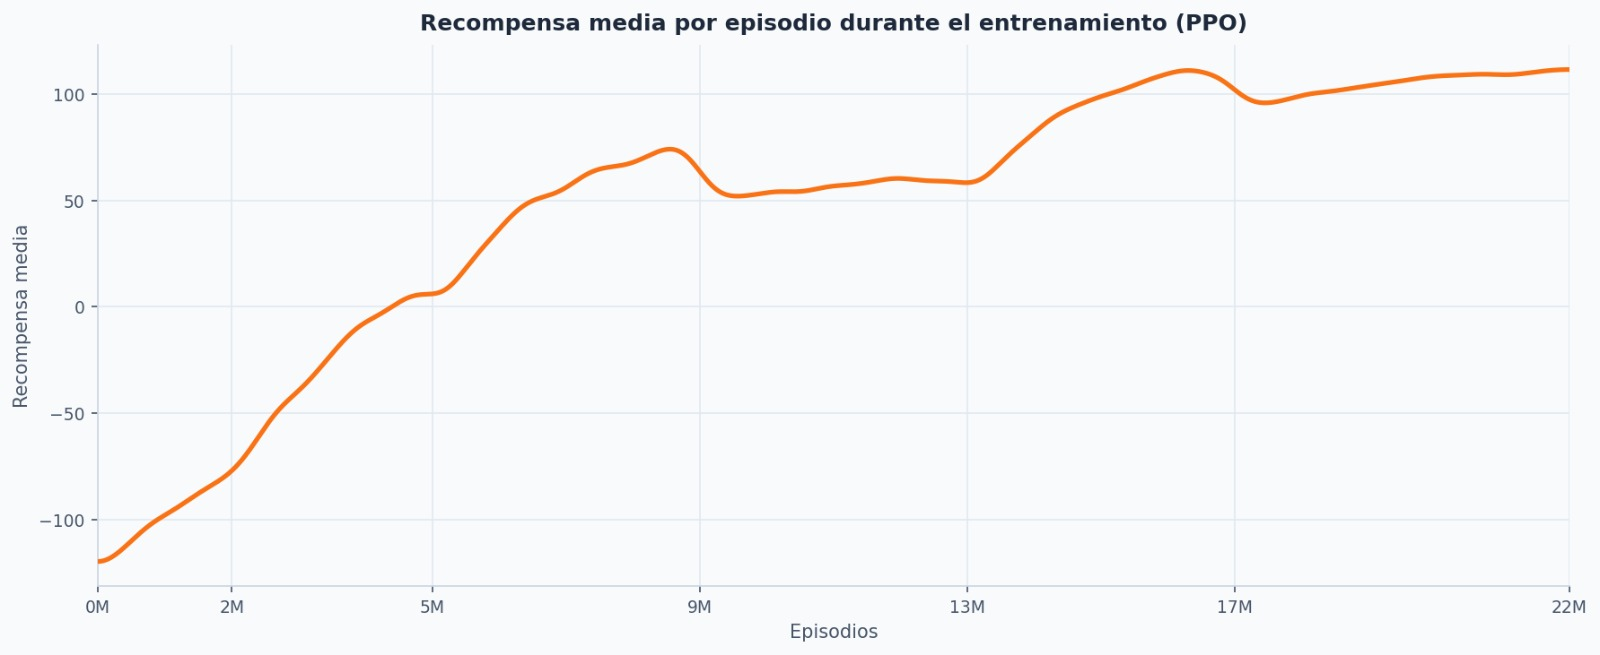

In [4]:
display(Image(filename='graficas_2.jpeg'))

*Figura 2. Recompensa media por episodio durante los 22 millones de episodios de entrenamiento. Los puntos dispersos representan recompensas individuales; la línea naranja es la media suavizada con filtro gaussiano.*

La evolución sigue un patrón característico con seis fases distinguibles:

| Fase | Episodios | Descripción | Recompensa media |
|------|-----------|-------------|------------------|
| 1 | 0–2M | Política casi aleatoria, aprendizaje mínimo | ~−100 |
| 2 | 2M–5M | Primeras estrategias de supervivencia | −80 → 0 |
| 3 | 5M–9M | 1ª revisión de recompensas (caída + recuperación) | 0 → 55 |
| 4 | 9M–13M | Meseta: domina niveles 1-2, no progresa | ~55–65 |
| 5 | 13M–17M | 2ª revisión de recompensas (rompe meseta) | 65 → 90 |
| 6 | 17M–22M | Convergencia asintótica | ~108–115 |

## 6. Conclusiones y Trabajo Futuro

### Resultados PPO

El agente ha aprendido a jugar a los cuatro niveles del juego personalizado, alcanzando una recompensa media de ~115 puntos por episodio. No comentamos los tres primeros niveles, ya que son relativamente sencillos y el agente los domina con facilidad. El nivel 4, con el BrainCell, es el verdadero desafío.

En todas las pruebas, es capaz de alcanzar el nivel 4 y la segunda fase del jefe final, aunque la tasa de éxito en derrotar al BrainCell es de aproximadamente el 10% debido a la alta dificultad de esa fase.

En general, suele fallar cuando el número de aliens en pantalla es alto (más de 10), lo que sugiere que aún no ha aprendido a que tiene que eliminarlos de forma eficiente para evitar ser rodeado. Sin embargo, es capaz de esquivar proyectiles con bastante eficacia, lo que indica que ha aprendido a detectar patrones de movimiento y anticipar las trayectorias.

Además de eso, es capaz de adaptarse en situaciones abrumadoras para una persona normal. 

Además de eso, ha descubierto que se generan naves durante la fase final del jefe, y ha aprendido a priorizarlas para evitar que se acumulen (de vez en cuando deja de disparar al jefe para eliminar esas naves, lo que es un comportamiento emergente no programado explícitamente). Además de eso, parece priorizarlo ya que sabe que le da vidas extra y puntos adicionales. 

### Limitaciones y Trabajo Futuro

Aunque el agente ha alcanzado un rendimiento sólido, aún hay margen de mejora, especialmente en la fase final del jefe. 

- **Mejorar la tasa de victoria contra el BrainCell**: Actualmente es del 10%. Se podrían probar técnicas de entrenamiento más avanzadas, como *self-play* o curriculum learning específico para esa fase. O simplemente entrenar exclusivamente en esa fase para que el agente se especialice.

- **No malgastar balas**: A veces el agente dispara sin necesidad, lo que puede ser peligroso en niveles avanzados. Se podría introducir una penalización leve por disparar para incentivar un uso más estratégico de las balas.

- **Conseguir corazones cuando no es necesario**: A veces el agente recoge corazones incluso cuando tiene vidas de sobra, lo que puede ser un desperdicio de tiempo. Se podría introducir una penalización leve por recoger corazones innecesarios para incentivar un uso más eficiente del tiempo.


En cuanto a las principales limitaciones, ha sido el tiempo de cómputo (no ha habido recursos para entrenar durante meses como en proyectos de DeepMind o OpenAI), lo que ha limitado la experimentación con arquitecturas más complejas o técnicas de entrenamiento más avanzadas. Sin embargo, el diseño iterativo de la función de recompensa ha sido clave para superar los obstáculos más importantes y alcanzar un rendimiento sólido con recursos limitados.

Además de eso, la complejidad del jefe final ha sido un gran desafío, y aunque el agente ha aprendido a enfrentarse a él, aún no lo domina completamente. 


En caso de tener más tiempo, se podría cambiar las recompensas para poder eliminar las mejoras que hemos mencionado anteriormente (por ejemplo, penalizar cada disparo innecesario o recoger corazones innecesarios) y así conseguir un agente más eficiente y estratégico, aunque eso requeriría un nuevo entrenamiento de varios millones de episodios.





